# Milestone 2 — CLIP + GPT-2 Image Captioning Training

This notebook covers the full Milestone 2 pipeline:
1. **Integration** — CLIP image encoder + GPT-2 decoder via prefix conditioning
2. **Training** — Mapping network + LoRA fine-tuning on COCO Captions
3. **Generation** — Baseline caption generation on sample images
4. **Decoding strategies** — Greedy vs beam search vs nucleus sampling

**Run on Google Colab:** Runtime → Change runtime type → **GPU (T4)**

**GitHub:** [heisenberg1804/image-captioning-with-CLIP-and-GPT-2](https://github.com/heisenberg1804/image-captioning-with-CLIP-and-GPT-2)

---
## 0. Install Dependencies & Setup

In [1]:
!pip install -q torch torchvision transformers datasets peft accelerate
!pip install -q Pillow matplotlib tqdm ftfy regex

In [2]:
import os
import re
import io
import json
import random
import urllib.request
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    CLIPModel, CLIPProcessor,
    GPT2LMHeadModel, GPT2Tokenizer,
    get_linear_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from PIL import Image

# Device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Apple MPS")
else:
    DEVICE = torch.device("cpu")
    print("CPU — training will be slow")

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

OUTPUT_DIR = Path("./outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

GPU: Tesla T4


---
## 1. Configuration

In [3]:
class Config:
    # Dataset
    dataset_name = "yerevann/coco-karpathy"
    train_size = 2500
    val_size = 500

    # Models
    clip_model_name = "openai/clip-vit-base-patch32"
    gpt2_model_name = "gpt2"

    # Architecture
    clip_dim = 512
    gpt2_dim = 768
    prefix_length = 10
    mapping_hidden_dim = 512

    # LoRA
    lora_r = 8
    lora_alpha = 16
    lora_dropout = 0.05

    # Training
    epochs = 5
    batch_size = 16
    learning_rate = 2e-4
    weight_decay = 0.01
    warmup_steps = 100
    max_caption_length = 64
    grad_accum_steps = 2

cfg = Config()
print("Config ready.")

Config ready.


---
## 2. Data Loading & Preprocessing

In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def clean_caption(caption):
    caption = caption.lower().strip()
    caption = re.sub(r"[^a-zA-Z0-9\s.,!?\'\-]", "", caption)
    caption = re.sub(r"\s+", " ", caption)
    return caption


def is_valid_caption(caption, min_words=4, max_words=60):
    return min_words <= len(caption.split()) <= max_words


def download_image(url, timeout=10):
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=timeout) as resp:
            img = Image.open(io.BytesIO(resp.read()))
        return img.convert("RGB")
    except Exception:
        return None

def load_split(split, target_size, seed):
    """Load and preprocess a split of COCO Karpathy with parallel downloads."""
    print(f"Loading {split} split (target: {target_size})...")
    ds = load_dataset(cfg.dataset_name, split=split)
    random.seed(seed)
    indices = random.sample(range(len(ds)), min(target_size * 2, len(ds)))

    # Prepare items for parallel download
    items_to_download = []
    for idx in indices:
        if len(items_to_download) >= target_size * 2:
            break
        item = ds[idx]
        captions = item.get("sentences", [])
        url = item.get("url", "")
        if not captions or not url:
            continue
        cleaned = [clean_caption(c) for c in captions if len(c.split()) >= 4]
        if not cleaned:
            continue
        items_to_download.append({"url": url, "captions": cleaned})

    # Parallel image download (8 threads)
    def fetch(item):
        img = download_image(item["url"])
        if img is not None:
            return {"image": img, "captions": item["captions"]}
        return None

    data = []
    print(f"  Downloading images with 8 threads...")
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(fetch, item): item for item in items_to_download}
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"Downloading {split}"):
            if len(data) >= target_size:
                break
            result = future.result()
            if result is not None:
                data.append(result)

    print(f"  Got {len(data)} pairs")
    return data

In [5]:
train_data = load_split("train", cfg.train_size, SEED)
val_data = load_split("validation", cfg.val_size, SEED + 1)

Loading train split (target: 2500)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  Got 2500 pairs
Loading validation split (target: 500)...


  Got 500 pairs


---
## 3. Pre-compute CLIP Embeddings

We encode all images through CLIP **once** before training. This avoids re-encoding every epoch and significantly speeds up training.

In [6]:
print("Loading CLIP...")
clip_model = CLIPModel.from_pretrained(cfg.clip_model_name).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(cfg.clip_model_name)
clip_model.eval()


def precompute_embeddings(data):
    embeddings = []
    for item in tqdm(data, desc="CLIP encoding"):
        inputs = clip_processor(images=item["image"], return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            vision_out = clip_model.vision_model(**inputs)
            emb = clip_model.visual_projection(vision_out.pooler_output)
        embeddings.append(emb.squeeze().cpu())
    return torch.stack(embeddings)


train_embs = precompute_embeddings(train_data)
val_embs = precompute_embeddings(val_data)
print(f"Train embeddings: {train_embs.shape} | Val embeddings: {val_embs.shape}")

# Free CLIP from GPU
del clip_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Loading CLIP...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP encoding:   0%|          | 0/2500 [00:00<?, ?it/s]

CLIP encoding:   0%|          | 0/500 [00:00<?, ?it/s]

Train embeddings: torch.Size([2500, 512]) | Val embeddings: torch.Size([500, 512])


---
## 4. Model Architecture

Three components:
- **MappingNetwork**: MLP that projects CLIP's 512-dim embedding → 10 prefix tokens in GPT-2's 768-dim space
- **GPT-2 + LoRA**: Language model fine-tuned with low-rank adapters on attention layers
- **CaptioningModel**: Wraps both together, handles prefix injection and loss computation

This is **prefix conditioning** — the image information is prepended to the text sequence as learned pseudo-tokens.

In [7]:
class MappingNetwork(nn.Module):
    """CLIP [512] → MLP → [prefix_length × 768]"""
    def __init__(self, clip_dim=512, gpt2_dim=768, prefix_length=10, hidden_dim=512):
        super().__init__()
        self.prefix_length = prefix_length
        self.gpt2_dim = gpt2_dim
        self.mlp = nn.Sequential(
            nn.Linear(clip_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, gpt2_dim * prefix_length),
        )

    def forward(self, clip_embedding):
        prefix = self.mlp(clip_embedding)
        return prefix.view(-1, self.prefix_length, self.gpt2_dim)


class CaptioningModel(nn.Module):
    """Full model: CLIP prefix → GPT-2 generates caption."""
    def __init__(self, gpt2_model, mapping_network, prefix_length, pad_token_id):
        super().__init__()
        self.gpt2 = gpt2_model
        self.mapping = mapping_network
        self.prefix_length = prefix_length
        self.pad_token_id = pad_token_id

    def forward(self, clip_embedding, input_ids, attention_mask):
        B = clip_embedding.shape[0]
        device = input_ids.device

        prefix_embeds = self.mapping(clip_embedding)
        token_embeds = self.gpt2.transformer.wte(input_ids)
        combined_embeds = torch.cat([prefix_embeds, token_embeds], dim=1)

        prefix_mask = torch.ones(B, self.prefix_length, device=device)
        combined_mask = torch.cat([prefix_mask, attention_mask], dim=1)

        outputs = self.gpt2(inputs_embeds=combined_embeds, attention_mask=combined_mask)
        logits = outputs.logits

        caption_logits = logits[:, self.prefix_length - 1:-1, :]
        loss = nn.functional.cross_entropy(
            caption_logits.reshape(-1, caption_logits.size(-1)),
            input_ids.reshape(-1),
            ignore_index=self.pad_token_id,
        )
        return loss, logits

    # ── Decoding strategies ────────────────────────

    @torch.no_grad()
    def generate_greedy(self, clip_embedding, tokenizer, max_length=50):
        """Greedy: always pick highest probability token."""
        self.eval()
        prefix = self.mapping(clip_embedding.unsqueeze(0))
        current = prefix
        generated = []
        for _ in range(max_length):
            logits = self.gpt2(inputs_embeds=current).logits[:, -1, :]
            token = logits.argmax(dim=-1)
            if token.item() == tokenizer.eos_token_id:
                break
            generated.append(token.item())
            current = torch.cat([current, self.gpt2.transformer.wte(token.unsqueeze(0))], dim=1)
        return tokenizer.decode(generated, skip_special_tokens=True)

    @torch.no_grad()
    def generate_beam(self, clip_embedding, tokenizer, max_length=50, beam_width=5):
        """Beam search: maintain top-k candidates."""
        self.eval()
        prefix = self.mapping(clip_embedding.unsqueeze(0))
        beams = [(0.0, [], prefix)]

        for _ in range(max_length):
            candidates = []
            for lp, toks, embs in beams:
                if toks and toks[-1] == tokenizer.eos_token_id:
                    candidates.append((lp, toks, embs))
                    continue
                logits = self.gpt2(inputs_embeds=embs).logits[:, -1, :]
                log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)
                top_probs, top_ids = log_probs.topk(beam_width)
                for p, t in zip(top_probs, top_ids):
                    new_embs = torch.cat([embs, self.gpt2.transformer.wte(t.unsqueeze(0).unsqueeze(0))], dim=1)
                    candidates.append((lp + p.item(), toks + [t.item()], new_embs))
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
            if all(b[1] and b[1][-1] == tokenizer.eos_token_id for b in beams):
                break

        best = beams[0][1]
        if best and best[-1] == tokenizer.eos_token_id:
            best = best[:-1]
        return tokenizer.decode(best, skip_special_tokens=True)

    @torch.no_grad()
    def generate_nucleus(self, clip_embedding, tokenizer, max_length=50,
                         temperature=0.8, top_p=0.9):
        """Nucleus (top-p) sampling."""
        self.eval()
        prefix = self.mapping(clip_embedding.unsqueeze(0))
        current = prefix
        generated = []
        for _ in range(max_length):
            logits = self.gpt2(inputs_embeds=current).logits[:, -1, :] / temperature
            sorted_logits, sorted_idx = torch.sort(logits, descending=True)
            cum_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
            remove = cum_probs - torch.softmax(sorted_logits, dim=-1) >= top_p
            sorted_logits[remove] = -float("inf")
            probs = torch.softmax(sorted_logits, dim=-1)
            token_idx = torch.multinomial(probs, 1)
            token = sorted_idx.gather(-1, token_idx)
            if token.item() == tokenizer.eos_token_id:
                break
            generated.append(token.item())
            current = torch.cat([current, self.gpt2.transformer.wte(token)], dim=1)
        return tokenizer.decode(generated, skip_special_tokens=True)


print("Model classes defined.")

Model classes defined.


---
## 5. Dataset & DataLoaders

In [8]:
class CaptionDataset(Dataset):
    """Pairs CLIP embeddings with randomly selected tokenized captions."""
    def __init__(self, clip_embeddings, captions_list, tokenizer, max_length=64):
        self.clip_embeddings = clip_embeddings
        self.captions_list = captions_list
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.clip_embeddings)

    def __getitem__(self, idx):
        emb = self.clip_embeddings[idx]
        caption = random.choice(self.captions_list[idx])
        tokens = self.tokenizer(
            caption + self.tokenizer.eos_token,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return emb, tokens["input_ids"].squeeze(), tokens["attention_mask"].squeeze()

In [9]:
# Load GPT-2 with LoRA
print("Loading GPT-2 with LoRA...")
gpt2_model = GPT2LMHeadModel.from_pretrained(cfg.gpt2_model_name)
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    target_modules=["c_attn", "c_proj"],
)
gpt2_model = get_peft_model(gpt2_model, lora_config)
gpt2_model.print_trainable_parameters()

# Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(cfg.gpt2_model_name)
tokenizer.pad_token = tokenizer.eos_token

# Mapping network + full model
mapping_net = MappingNetwork(
    clip_dim=cfg.clip_dim, gpt2_dim=cfg.gpt2_dim,
    prefix_length=cfg.prefix_length, hidden_dim=cfg.mapping_hidden_dim,
)
model = CaptioningModel(gpt2_model, mapping_net, cfg.prefix_length, tokenizer.eos_token_id).to(DEVICE)

# Datasets
train_caps = [d["captions"] for d in train_data]
val_caps = [d["captions"] for d in val_data]

train_dataset = CaptionDataset(train_embs, train_caps, tokenizer, cfg.max_caption_length)
val_dataset = CaptionDataset(val_embs, val_caps, tokenizer, cfg.max_caption_length)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Loading GPT-2 with LoRA...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 2500 | Val: 500


---
## 6. Training Loop

Each epoch:
1. Train on all batches with gradient accumulation
2. Validate and compute average loss
3. Generate sample captions using all 3 decoding strategies
4. Save best checkpoint based on validation loss

In [10]:
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=cfg.learning_rate,
    weight_decay=cfg.weight_decay,
)

total_steps = (len(train_loader) // cfg.grad_accum_steps) * cfg.epochs
scheduler = get_linear_schedule_with_warmup(optimizer, cfg.warmup_steps, total_steps)

training_log = []
train_losses = []
val_losses = []
best_val_loss = float("inf")

print(f"Training for {cfg.epochs} epochs ({total_steps} optimizer steps)")
print(f"Effective batch size: {cfg.batch_size * cfg.grad_accum_steps}")
print("=" * 60)

for epoch in range(cfg.epochs):
    # --- Train ---
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs} [Train]")
    for step, (emb, ids, mask) in enumerate(pbar):
        emb, ids, mask = emb.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
        loss, _ = model(emb, ids, mask)
        loss = loss / cfg.grad_accum_steps
        loss.backward()

        if (step + 1) % cfg.grad_accum_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        epoch_loss += loss.item() * cfg.grad_accum_steps
        pbar.set_postfix(loss=f"{loss.item() * cfg.grad_accum_steps:.4f}")

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # --- Validate ---
    model.eval()
    vl = 0
    with torch.no_grad():
        for emb, ids, mask in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            emb, ids, mask = emb.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
            loss, _ = model(emb, ids, mask)
            vl += loss.item()
    avg_val = vl / len(val_loader)
    val_losses.append(avg_val)

    # --- Sample captions ---
    s_emb = val_embs[0].to(DEVICE)
    greedy = model.generate_greedy(s_emb, tokenizer)
    beam = model.generate_beam(s_emb, tokenizer, beam_width=5)
    nucleus = model.generate_nucleus(s_emb, tokenizer, temperature=0.8, top_p=0.9)

    epoch_log = {
        "epoch": epoch + 1,
        "train_loss": round(avg_train, 4),
        "val_loss": round(avg_val, 4),
        "sample_gt": val_caps[0][0],
        "sample_greedy": greedy,
        "sample_beam": beam,
        "sample_nucleus": nucleus,
    }
    training_log.append(epoch_log)

    print(f"\nEpoch {epoch+1}: Train={avg_train:.4f} | Val={avg_val:.4f}")
    print(f"  GT:      \"{val_caps[0][0]}\"")
    print(f"  Greedy:  \"{greedy}\"")
    print(f"  Beam:    \"{beam}\"")
    print(f"  Nucleus: \"{nucleus}\"")

    # --- Checkpoint ---
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": avg_val,
        }, CHECKPOINT_DIR / "best_model.pt")
        print(f"  Saved best model (val_loss={avg_val:.4f})")

# Save log
with open(OUTPUT_DIR / "training_log.json", "w") as f:
    json.dump(training_log, f, indent=2)
print(f"\nTraining complete. Log saved.")

Training for 5 epochs (390 optimizer steps)
Effective batch size: 32


Epoch 1/5 [Train]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]


Epoch 1: Train=4.7619 | Val=3.3115
  GT:      "a table in the sun with a white cloth, beef sandwich, glass of beer, and bottle of wine."
  Greedy:  "a large plate of chicken and cheese.

I'm not sure if I'm going to eat it. I'm not sure if I'm going to eat it. I'm not sure if I'm going to eat it.

I'm"
  Beam:    "a hot dog with a hot dog on it. It's a hot dog with a hot dog on it. It's a hot dog with a hot dog on it. It's a hot dog with a hot dog on it. It's a hot"
  Nucleus: "my food with vegetables and bread. When I make the croissants and bread, I'll add them to the hot food. I like to make them at least once a week and the food gets crispy and crispy. I like to do it in"
  Saved best model (val_loss=3.3115)


Epoch 2/5 [Train]:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 4 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]


Epoch 4: Train=2.8310 | Val=2.7950
  GT:      "a table in the sun with a white cloth, beef sandwich, glass of beer, and bottle of wine."
  Greedy:  "a plate of food with a large plate of food on it. The food is covered in a sauce. The food is covered in a sauce. The food is covered in a sauce. The food is covered in a sauce. The food is covered in"
  Beam:    "a plate of food on a table with a glass of wine on top. The glasses are on top of each other. The glasses are on top of each other. The glasses are on top of each other. The glasses are on top of each other"
  Nucleus: "a plate of beer and pizza on a plate with a slice of pizza. It is covered in cheese. The chef is serving a red salad. The pizza is being served on a plate.

This is a plate of cheese with some toppings"
  Saved best model (val_loss=2.7950)


Epoch 5/5 [Train]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 5 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]


Epoch 5: Train=2.8159 | Val=2.7300
  GT:      "a table in the sun with a white cloth, beef sandwich, glass of beer, and bottle of wine."
  Greedy:  "a plate of food is sitting on top of a plate. The food is covered in a sauce. The food is covered in a sauce. The food is covered in a sauce. The food is covered in a sauce. The food is covered in a"
  Beam:    "a plate of food is sitting on top of a plate. The food is sitting on top of a plate. The food is sitting on top of a plate. The food is sitting on top of a plate. The food is sitting on top of a"
  Nucleus: "a large pizza on a plate and a brown paper towel next to it. The pizza is decorated with toppings. On a white table in a kitchen, the pizza is open with some toppings.

In the kitchen, the pizza is covered"
  Saved best model (val_loss=2.7300)

Training complete. Log saved.


---
## 7. Training Curves

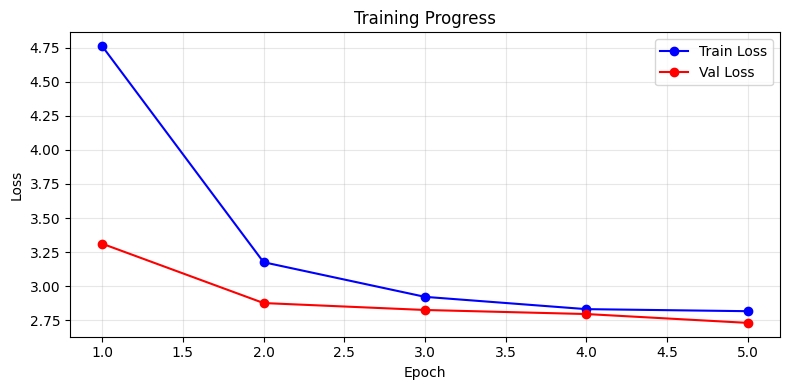

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, "b-o", label="Train Loss")
ax.plot(epochs_range, val_losses, "r-o", label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Progress")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()

---
## 8. Caption Generation — Decoding Strategy Comparison

Compare **greedy**, **beam search**, and **nucleus sampling** on 5 validation images.

In [12]:
# Load best checkpoint
ckpt = torch.load(CHECKPOINT_DIR / "best_model.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model from epoch {ckpt['epoch']+1} (val_loss={ckpt['val_loss']:.4f})")

Loaded best model from epoch 5 (val_loss=2.7300)


In [13]:
N_DEMO = 5
model.eval()

print("=" * 80)
print("DECODING STRATEGY COMPARISON")
print("=" * 80)

demo_results = []

for i in range(N_DEMO):
    emb = val_embs[i].to(DEVICE)
    gt = val_caps[i][0]
    g = model.generate_greedy(emb, tokenizer)
    b = model.generate_beam(emb, tokenizer, beam_width=5)
    n = model.generate_nucleus(emb, tokenizer, temperature=0.8, top_p=0.9)

    demo_results.append({
        "image": val_data[i]["image"],
        "gt": gt, "greedy": g, "beam": b, "nucleus": n,
    })

    print(f"\n--- Sample {i+1} ---")
    print(f"  GT:      {gt}")
    print(f"  Greedy:  {g}")
    print(f"  Beam:    {b}")
    print(f"  Nucleus: {n}")

DECODING STRATEGY COMPARISON

--- Sample 1 ---
  GT:      a table in the sun with a white cloth, beef sandwich, glass of beer, and bottle of wine.
  Greedy:  a plate of food is sitting on top of a plate. The food is covered in a sauce. The food is covered in a sauce. The food is covered in a sauce. The food is covered in a sauce. The food is covered in a
  Beam:    a plate of food is sitting on top of a plate. The food is sitting on top of a plate. The food is sitting on top of a plate. The food is sitting on top of a plate. The food is sitting on top of a
  Nucleus: a person in a large plate with a bowl of food on it. The person is holding a glass of beer. They are eating in a restaurant. The person is sitting on a table with a beer and a spoon. The person is eating. The

--- Sample 2 ---
  GT:      a person is doing a trick over a trash can.
  Greedy:  a man is riding a skateboard on a sidewalk. The skateboard is on top of a tree. The man is holding a skateboard. The man is holding a

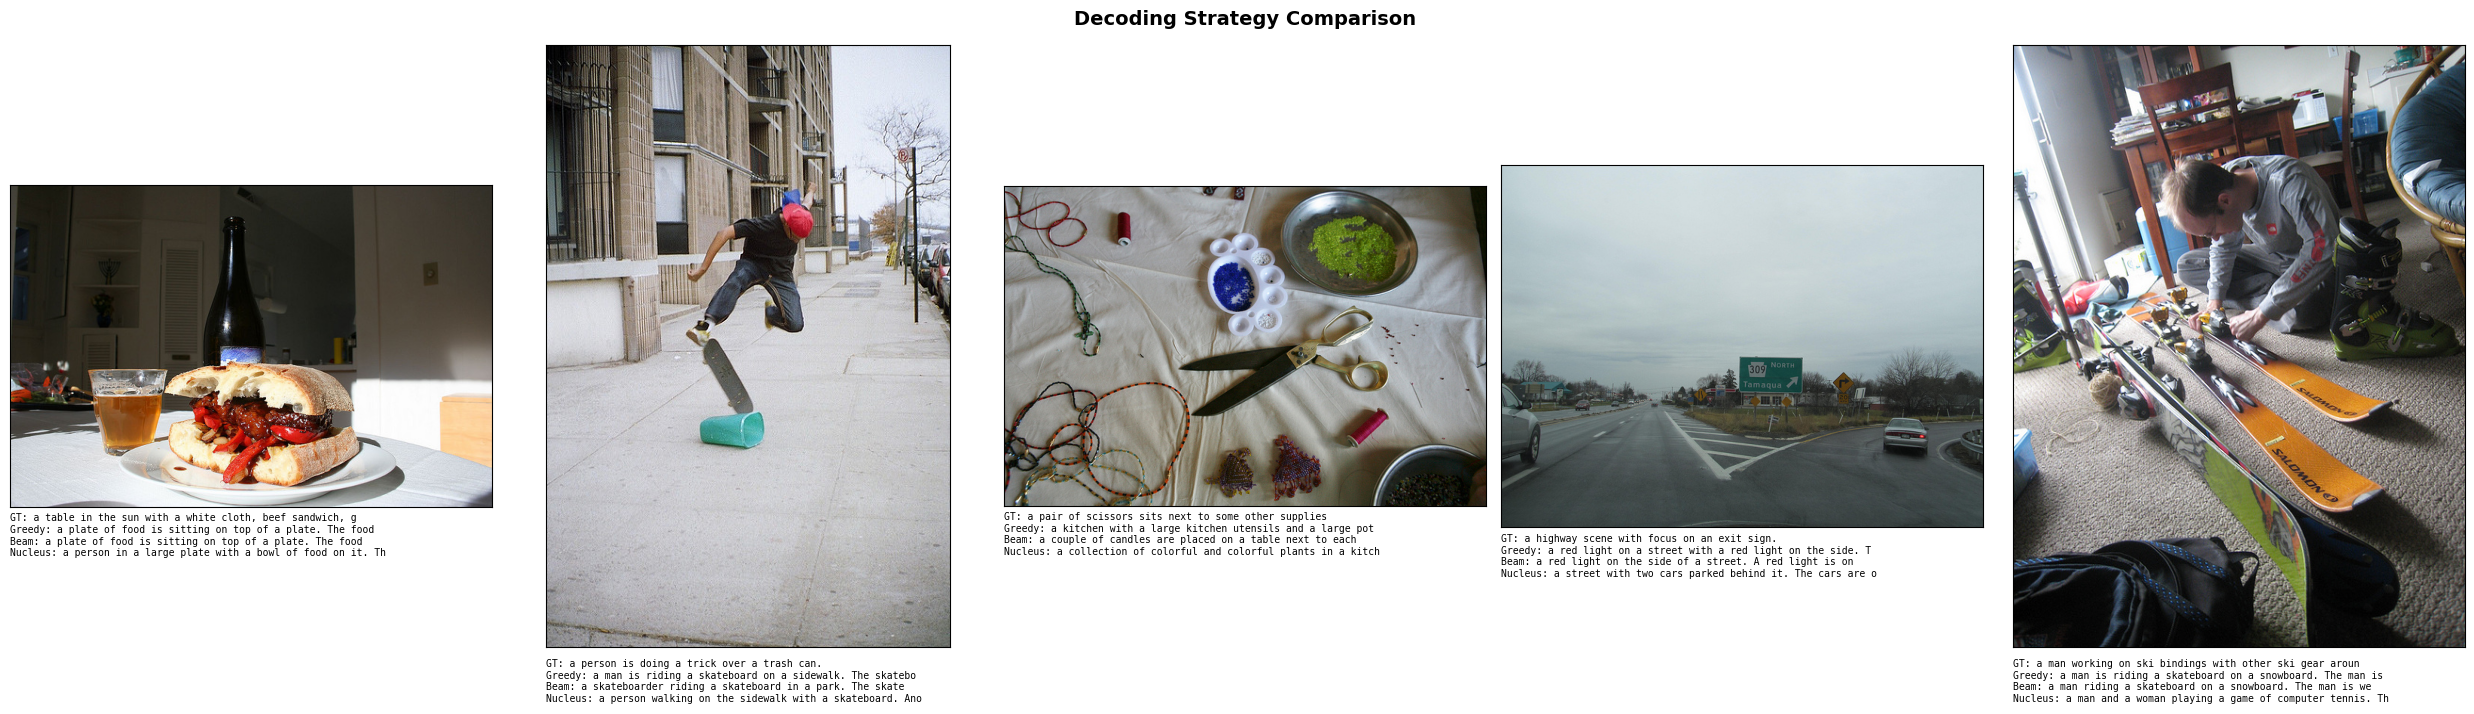

Saved → outputs/decoding_comparison.png


In [14]:
# Visual comparison grid
fig, axes = plt.subplots(1, N_DEMO, figsize=(5 * N_DEMO, 7))

for ax, res in zip(axes, demo_results):
    ax.imshow(res["image"])
    caption_text = (
        f"GT: {res['gt'][:55]}\n"
        f"Greedy: {res['greedy'][:55]}\n"
        f"Beam: {res['beam'][:55]}\n"
        f"Nucleus: {res['nucleus'][:55]}"
    )
    ax.set_xlabel(caption_text, fontsize=7, family="monospace", ha="left")
    ax.xaxis.set_label_coords(0, -0.02)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Decoding Strategy Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decoding_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR / 'decoding_comparison.png'}")

---
## 9. Training Log Summary

In [15]:
print("\n" + "=" * 90)
print(f"{'Epoch':<7} {'Train Loss':<12} {'Val Loss':<12} {'Greedy Sample':<60}")
print("-" * 90)
for log in training_log:
    print(f"{log['epoch']:<7} {log['train_loss']:<12} {log['val_loss']:<12} {log['sample_greedy'][:58]}")
print("=" * 90)


Epoch   Train Loss   Val Loss     Greedy Sample                                               
------------------------------------------------------------------------------------------
1       4.7619       3.3115       a large plate of chicken and cheese.

I'm not sure if I'm 
2       3.1756       2.8757       a large plate of pizza with a large slice of cheese on top
3       2.9212       2.8248       a plate of pizza with a pizza on top. The pizza is on top 
4       2.831        2.795        a plate of food with a large plate of food on it. The food
5       2.8159       2.73         a plate of food is sitting on top of a plate. The food is 


---
## 10. Summary & Observations

### Architecture
- **Embedding injection method:** Prefix conditioning — CLIP embeddings are projected into a sequence of 10 pseudo-tokens prepended to GPT-2's input
- **Trainable components:** Mapping network (MLP) + GPT-2 LoRA adapters (~0.5-1% of GPT-2 params)
- **Frozen components:** CLIP ViT-B/32

### Decoding Strategies
| Strategy | Behavior | Trade-off |
|----------|----------|-----------|
| Greedy | Picks highest probability token at each step | Fast, but repetitive and less diverse |
| Beam search (k=5) | Maintains top-5 candidates, picks best overall | More coherent, but can be generic |
| Nucleus (p=0.9) | Samples from top-90% probability mass | Most diverse, but occasionally noisy |

### Milestone 2 Deliverables
| Deliverable | Status |
|-------------|--------|
| CLIP + GPT-2 integration with prefix conditioning | ✅ |
| Training loop with logging and checkpointing | ✅ |
| Baseline caption generation on sample images | ✅ |
| Decoding strategy comparison (greedy, beam, nucleus) | ✅ |
| Training log and early caption samples | ✅ |

In [16]:
# Download outputs (for Colab)
try:
    from google.colab import files
    files.download(str(OUTPUT_DIR / "training_log.json"))
    files.download(str(OUTPUT_DIR / "training_curves.png"))
    files.download(str(OUTPUT_DIR / "decoding_comparison.png"))
    print("Files downloaded.")
except ImportError:
    print("Not on Colab — files saved locally in outputs/")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded.
